# Function 4 Analysis - Week 2

This notebook contains the exploratory analysis for **Function 4** in Week 2. After incorporating last week’s query we now have **31 datapoints** to model (the original 30 plus the new observation).

**Function Description:** Address the challenge of optimally placing products across warehouses for a business with high online sales, where accurate calculations are costly and only feasible biweekly. To speed up decision-making, an ML model approximates these results within hours. The model has four hyperparameters to tune, and its output reflects the difference from the expensive baseline. Because the system is dynamic and full of local optima, it requires careful tuning and robust validation to find reliable, near-optimal solutions.


## Loading and Displaying the Data

We load the inputs and outputs for function 4 and display them in a table format to inspect the raw data values. All data seems normalised to [0,1]. The new point we added (low x1/x4, moderate x2/x3) produced a disappointing negative value, which suggests that simply pushing x4 close to zero is not sufficient once the other hyperparameters drift away from the narrow basin we identified earlier.


In [1]:
from pathlib import Path
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
from IPython.display import display
sns.set_theme(style="ticks", context="notebook")
path = Path("../../initial_data/function_4")
X = np.load(path / "initial_inputs.npy")
y = np.load(path / "initial_outputs.npy")
new_x = np.array([[0.100000, 0.400000, 0.400000, 0.050000]])
new_y = np.array([-11.551402216263181])
X = np.vstack([X, new_x])
y = np.concatenate([y, new_y])
df = pd.DataFrame(X, columns=["x1", "x2", "x3", "x4"])
df["y"] = y

# Display original and y-sorted DataFrames side by side
display(df)
print("df sorted by y")
df_sorted = df.sort_values("y", ascending=False).reset_index(drop=True)
df_sorted["x_avg"] = df_sorted[["x1", "x2", "x3", "x4"]].mean(axis=1)
display(df_sorted)


,x1,x2,x3,x4,y
0,0.896981,0.725628,0.175404,0.701694,-22.108288
1,0.889356,0.499588,0.539269,0.508783,-14.601397
2,0.250946,0.033693,0.145380,0.494932,-11.699932
3,0.346962,0.006250,0.760564,0.613024,-16.053765
4,0.124871,0.129770,0.384400,0.287076,-10.069633
5,0.801303,0.500231,0.706645,0.195103,-15.487083
6,0.247708,0.060445,0.042186,0.441324,-12.681685
7,0.746702,0.757092,0.369353,0.206566,-16.026400
8,0.400665,0.072574,0.886768,0.243842,-17.049235
9,0.626071,0.586751,0.438806,0.778858,-12.741766


df sorted by y


,x1,x2,x3,x4,y,x_avg
0,0.577766,0.428772,0.425826,0.249007,-4.025542,0.420343
1,0.326076,0.472367,0.453192,0.105887,-6.702089,0.339381
2,0.282138,0.505987,0.530531,0.096302,-7.966775,0.353739
3,0.124871,0.129770,0.384400,0.287076,-10.069633,0.231529
4,0.100000,0.400000,0.400000,0.050000,-11.551402,0.237500
5,0.170347,0.756959,0.276520,0.531231,-11.565742,0.433765
6,0.250946,0.033693,0.145380,0.494932,-11.699932,0.231238
7,0.247708,0.060445,0.042186,0.441324,-12.681685,0.197916
8,0.626071,0.586751,0.438806,0.778858,-12.741766,0.607621
9,0.216911,0.166086,0.241372,0.770062,-12.758324,0.348608


- **New point (Week 1):** The `(0.1, 0.4, 0.4, 0.05)` configuration came back with a moderately negative score (≈−11.6), signalling that our intuition about “just keep x4 tiny” was incomplete – the model punished us once x1 dropped too low, so we need to balance the quartet instead of chasing single-parameter extremes.


## Correlation Matrix

The correlation heatmap shows pairwise correlations between all variables (x1, x2, x3, x4, and y and x_avg). While no individual feature has a very high correlation (the best being x1 at -0.54), we see a relatively strong correlation with the x_avg (-0.73).


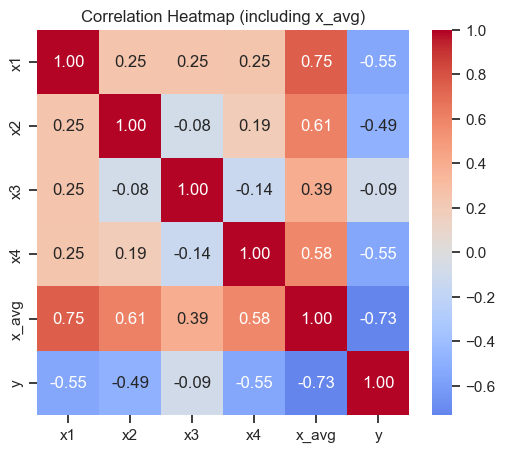

In [2]:
df_with_avg = df.copy()
df_with_avg["x_avg"] = df_with_avg[["x1", "x2", "x3", "x4"]].mean(axis=1)
plt.figure(figsize=(6, 5))
sns.heatmap(df_with_avg[["x1", "x2", "x3", "x4", "x_avg", "y"]].corr(), cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("Correlation Heatmap (including x_avg)")
plt.show()


## Pairplot Analysis

The pairplot provides a comprehensive view of pairwise relationships between all variables. The x_avg is the only variable that seems to visually confirm a significant negative correlation. 


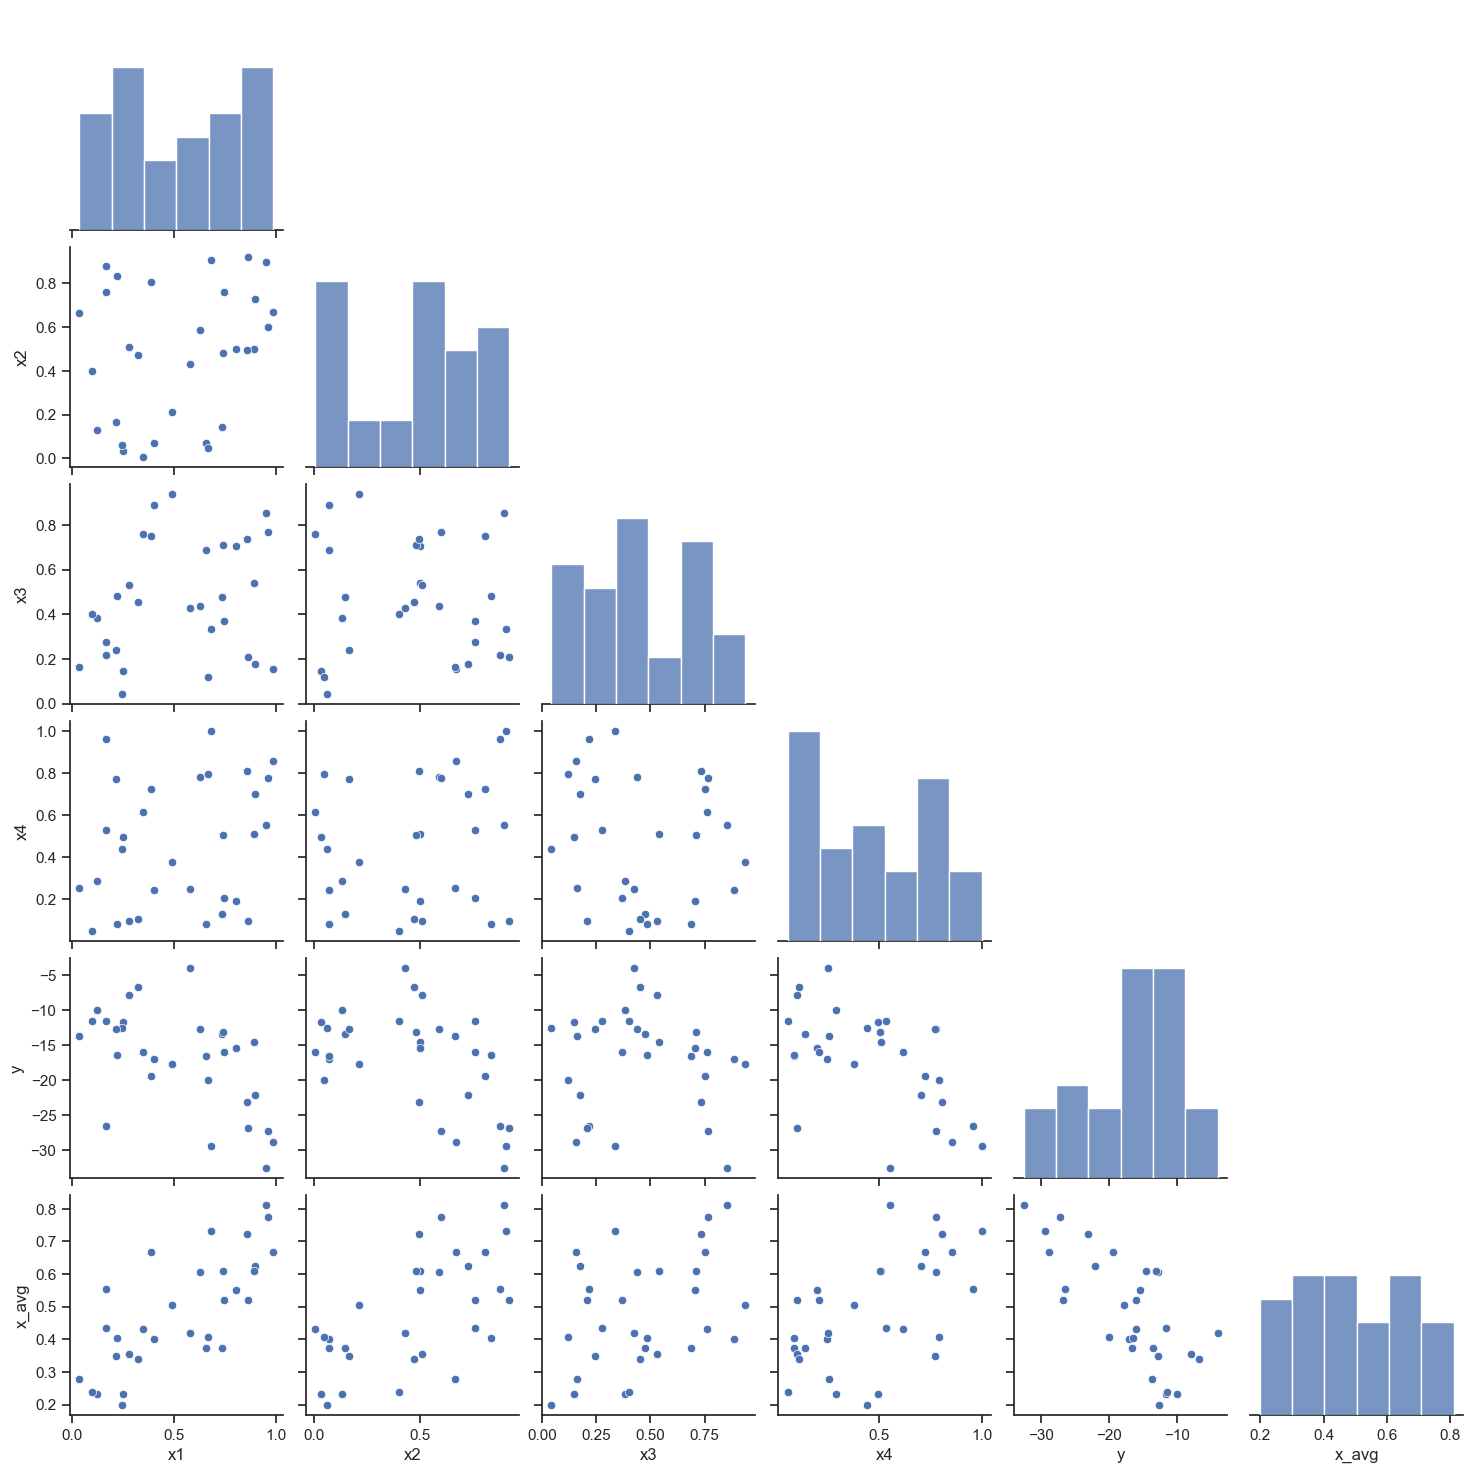

In [3]:
df_pairplot = df.copy()
df_pairplot["x_avg"] = df_pairplot[["x1", "x2", "x3", "x4"]].mean(axis=1)
sns.pairplot(df_pairplot, corner=True, diag_kind="hist")
plt.show()


## Conclusion from Exploratory Analysis

The exploratory data analysis suggests the function has complex, non-linear relationships or interactions between the four hyperparameters. However, we can see that on average, the best scores have low x values and the worst have high x values. This seems to be a non-necessary condition, as wel also see a few poor scores with low x values and moderately good scores with high x values. We expect the Bayesian optimisation to select a point in that region to confirm our intuition. 


## Bayesian Optimization Setup

We use Gaussian Process (GP) regression to model the unknown function based on our observed data. The GP provides both a mean prediction and uncertainty estimates. We use the Upper Confidence Bound (UCB) acquisition function to balance exploration (high uncertainty) and exploitation (high predicted mean). The search space is defined as [0, 1] for each of the four input variables.


In [4]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern
from scipy.optimize import minimize
np.random.seed(42)
kernel = Matern(length_scale=1.0, nu=2.5)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-6, normalize_y=True, n_restarts_optimizer=5)
gp.fit(X, y)
print("GP fitted successfully")


GP fitted successfully


## Finding the Next Point to Evaluate

We optimize the Upper Confidence Bound (UCB) acquisition function: UCB(x) = μ(x) + κ·σ(x), where μ(x) is the predicted mean, σ(x) is the predicted standard deviation, and κ is a parameter controlling the exploration-exploitation trade-off. We have adapted the optimisation to favour low x values on average, as this is in line with our intuition from EDA. 

In [5]:
kappa = 2.0
lambda_x = 2.0  # Weight to penalize higher x values

def ucb_with_low_x(x):
    x = x.reshape(1, -1)
    mu, sigma = gp.predict(x, return_std=True)
    x_mean = x.mean()
    # Encourage low x values by subtracting (positive) penalty proportional to average x
    return -(mu + kappa * sigma) + lambda_x * x_mean

bounds = [(0, 1), (0, 1), (0, 1), (0, 1)]
result = minimize(ucb_with_low_x, x0=np.random.uniform(0, 1, 4), bounds=bounds, method='L-BFGS-B')
next_point = result.x
mu_pred, sigma_pred = gp.predict(next_point.reshape(1, -1), return_std=True)
x_avg = next_point.mean()
print(f"Next point to evaluate: x1={next_point[0]:.4f}, x2={next_point[1]:.4f}, x3={next_point[2]:.4f}, x4={next_point[3]:.4f}")
print(f"x_avg = {x_avg:.4f}")
print(f"Predicted output: {mu_pred[0]:.4f} ± {sigma_pred[0]:.4f}")
print(f"Modified UCB value: {mu_pred[0] + kappa * sigma_pred[0] - lambda_x * x_avg:.4f}")


Next point to evaluate: x1=0.4120, x2=0.4482, x3=0.3863, x4=0.4395
x_avg = 0.4215
Predicted output: -1.9003 ± 1.6126
Modified UCB value: 0.4819


## Distance Analysis of Recommended Point

We calculate the Euclidean distance from the recommended point to all existing observations. This helps understand how similar the recommended point is to our current data. We also identify the three closest neighbors and compute the average of their y values to get a local estimate of the expected output.


In [6]:
distances = np.sqrt(((X - next_point)**2).sum(axis=1))
df_dist = pd.DataFrame({"point_index": range(len(X)), "distance": distances, "y": y})
df_dist = df_dist.sort_values("distance")
print("Euclidean distances from recommended point to all observations:")
print(df_dist.to_string(index=False))
closest_3 = df_dist.head(3)
avg_y = closest_3["y"].mean()
print(f"\nThree closest neighbors: points {closest_3['point_index'].tolist()}")
print(f"Average y value of closest 3 neighbors: {avg_y:.4f}")


Euclidean distances from recommended point to all observations:
 point_index  distance          y
          27  0.256303  -4.025542
          24  0.351736  -6.702089
          23  0.398466  -7.966775
          21  0.417391 -11.565742
           9  0.427760 -12.741766
           4  0.455025 -10.069633
          28  0.465159 -13.122782
          16  0.497922 -12.758324
          30  0.501532 -11.551402
           1  0.508648 -14.601397
           2  0.508763 -11.699932
           7  0.511843 -16.026400
          19  0.521242 -13.702747
           6  0.543807 -12.681685
          11  0.544584 -13.527649
           5  0.562682 -15.487083
          13  0.566584 -16.507159
          17  0.584859 -19.441558
           3  0.608060 -16.053765
          14  0.609393 -17.817999
          12  0.647274 -16.679115
          26  0.650692 -19.989498
           0  0.652243 -22.108288
           8  0.655712 -17.049235
          29  0.675195 -23.139428
          15  0.736750 -26.561821
          22  0.75

## Analysis and recommendation

This is a problem with 4 features, so it is more difficult to visualise. The relationships between features and output are non-linear and complex. Nonetheless, we identified that 1/ the best y values have low x values on average compared to the worst. 2/ the best y values have x2 and x3 closeby and 3/ the best y values have low x4 values. We build a Bayesian optimisation and verified the recommended point with the closest neighbours using Euclidian distances. The point is indeed close to the best y values, even if x4 is larger. Since this contradicted a bit the results of our EDA, and since we want to test out whether the low x4 is needed or whether it needs to be seen in conjuntion with x1, we manually change the recommended point to x1=0.1, x2=0.4, x3=0.4, x4=0.0.5 from initially x1=0.4154, x2=0.4481, x3=0.3821, x4=0.4418.